# Figure S2: Sensitivity of the AABW thickness at Cape Adare

## Only code but not data provided for supplementary figures

In [1]:
%matplotlib inline
import xarray as xr
import numpy as np
import cosima_cookbook as cc
from dask.distributed import Client
import cftime
import sys
sys.path.append(
    "/g/data/e14/cs6673/Ross_salinity/Python_scripts_published/") 
from Info_definitions import (
    path_database, path_output, path_plots, exptdict, yearly_mean)

import matplotlib.pyplot as plt
import string

In [2]:
plt.rcParams['figure.dpi'] = 96
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["lines.linewidth"] = 1.5
plt.rcParams["lines.markersize"] = 3
plt.rcParams['hatch.color'] = 'k'
plt.rcParams["savefig.facecolor"] = 'white'

In [ ]:
client = Client()
client

## Load data

In [4]:
%%time
ekeys = ['ctrl', 'wind_50_down_zonal', 'mw_50_down']
start_time = '2150-01-01'
end_time = '2159-12-31'

area_t = cc.querying.getvar(
    exptdict['ctrl']['expt'], 'area_t',
    session=cc.database.create_session(), frequency='static',  n=1,
    chunks={'yt_ocean': '200MB', 'xt_ocean': '200MB'}).sel(
    yt_ocean=slice(-76, -71), xt_ocean=slice(-198, -184))

for ekey in ekeys:
    print(ekey)
    e = exptdict[ekey]
    if ekey == 'ctrl':
        session = cc.database.create_session()
    else:
        db = (path_database + e['expt'] + '.db')
        session = cc.database.create_session(db)

    e['dzt'] = cc.querying.getvar(
        e['expt'], 'dzt', session, frequency='1 monthly',
        chunks={'yt_ocean': '100MB', 'xt_ocean': '100MB'}).sel(
        yt_ocean=slice(None, -60), xt_ocean=slice(-240, -60))

    e['rho0'] = cc.querying.getvar(
        e['expt'], 'pot_rho_0', session, frequency='1 monthly',
        start_time=start_time, end_time=end_time,
        chunks={'yt_ocean': '200MB', 'xt_ocean': '200MB'}).sel(
            yt_ocean=slice(None, -60), xt_ocean=slice(-240, -60)) - 1000

    # SWMT in southwestern Ross Sea
    ds_SWMT = xr.open_mfdataset(
        path_output + 'SWMT_in_AABW_formation_region_' + e['expt']  +
        '_1m_????.nc')
    ds_SWMT = ds_SWMT.sel(area='Ross').sel(
        time=slice(start_time[:4], end_time[:4]))
    e['swmt'] = yearly_mean(
        ds_SWMT.binned_salt_transformation_in_AABW_region +
        ds_SWMT.binned_heat_transformation_in_AABW_region).compute()

ctrl
wind_50_down_zonal
mw_50_down
CPU times: user 9.06 s, sys: 2.13 s, total: 11.2 s
Wall time: 33.3 s


## Plots

In [5]:
def Fig_S2(ekeys, region='Cape Adare', rho_AABW=np.arange(27.85, 27.88, .01)):
    fig = plt.figure(figsize=(12, len(rho_AABW)*1.2))
    plt.subplots_adjust(wspace=.12)

    """ sensitivity of AABW thickness to density threshold """

    for r in range(len(rho_AABW)):
        plt.subplot(int(len(rho_AABW)/2), 2, r+1)
        for ekey in ekeys:
            e = exptdict[ekey]
            if region == 'Cape Adare':
                thickAABW = e['dzt'].sel(
                    xt_ocean=slice(-191.5, -189.5), yt_ocean=slice(-70.3, -69))
            elif region == 'ABB':
                # Amundsen-Bellingshausen Basin
                thickAABW = e['dzt'].sel(
                    xt_ocean=slice(-172, -165), yt_ocean=slice(-71, -69))
            thickAABW = yearly_mean(
                thickAABW.where(e['rho0'] >= rho_AABW[r]).sum('st_ocean').mean(
                ['xt_ocean', 'yt_ocean']))
            plt.plot(np.arange(len(thickAABW.time)) + .5, thickAABW, marker='o',
                     color=e['col'], label=e['expt_str'])
        if r == 0:
            plt.legend(ncol=len(ekeys), loc='center', bbox_to_anchor=(1.05, 1.12))
        plt.xlim(0, len(thickAABW.time))
        plt.text(.01, .89, string.ascii_lowercase[r] + ') ' + r'$\sigma_0\geq$' +
                 str(np.round(rho_AABW[r], 2)),
                 fontweight='bold', transform=plt.gca().transAxes)
        if r > 1:
            plt.xlabel('Model year')        
    fig.supylabel('AABW thickness at Cape Adare (m)', fontsize=12, x=.065)
    
    plt.savefig(path_plots + 'FigS2.jpg', dpi=600, bbox_inches="tight")

    plt.show()

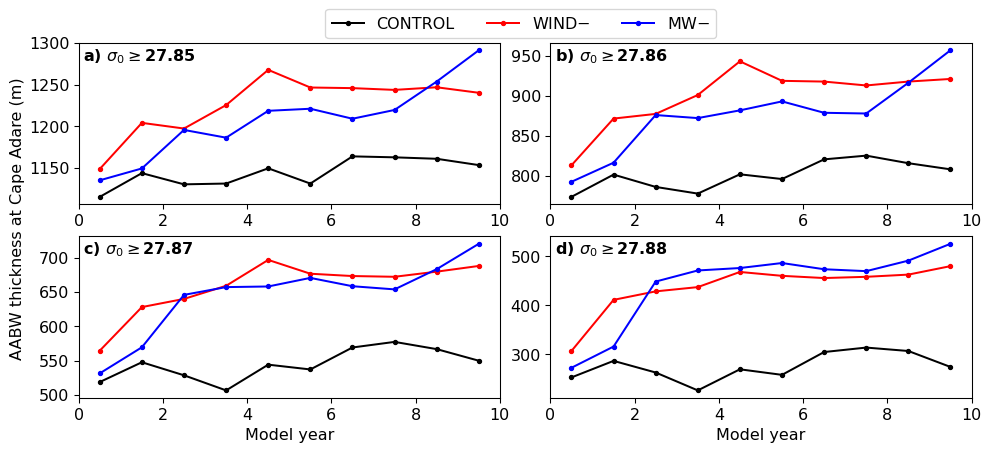

In [6]:
Fig_S2(ekeys, region='Cape Adare', rho_AABW=np.arange(27.85, 27.89, .01))

In [7]:
time_slice = slice('2155', '2159')
print('Mean SWMT in ' + time_slice.start + '-' + time_slice.stop)
print('')
print('Density thresholds based on CONTROL')
for ekey in ekeys:
    e = exptdict[ekey]
    if ekey == 'ctrl':
        # maximum SWMT of time mean 
        swmt_max = e['swmt'].mean('time')[e['swmt'].mean(
            'time').argmax('isopycnal_bins').values]
        # isopycnal bin corresponding to SWMT 75% and 25%
        # below its maximum value
        swmt_sig_bin_75 = e['swmt'].isopycnal_bins.sel(
            isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
            e['swmt'].mean('time') <= swmt_max*.75).min('isopycnal_bins')
        swmt_sig_bin_25 = e['swmt'].isopycnal_bins.sel(
            isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
            e['swmt'].mean('time') <= swmt_max*.25).min('isopycnal_bins')

    swmt = e['swmt'].sel(isopycnal_bins=slice(
        swmt_sig_bin_75, swmt_sig_bin_25)).mean('isopycnal_bins')
    if ekey == 'ctrl':
        swmt_ctrl = swmt.sel(time=time_slice).mean('time').values
        print(ekey, ':', np.round(swmt_ctrl, 2), ' Sv')
    else:
        swmt = swmt.sel(time=time_slice).mean('time').values
        print(ekey, ':', np.round(swmt, 2), ' Sv (+',
              np.round((swmt-swmt_ctrl), 2), ' Sv, +',
              np.round((swmt-swmt_ctrl)/swmt_ctrl*100, 1), '%)')

print('')
print('Density thresholds based on WIND-')
e = exptdict['wind_50_down_zonal']
# maximum SWMT of time mean 
swmt_max = e['swmt'].mean('time')[e['swmt'].mean('time').argmax(
    'isopycnal_bins').values]
# isopycnal bin corresponding to SWMT 75% and 25% below its maximum value
swmt_sig_bin_75 = e['swmt'].isopycnal_bins.sel(
    isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
    e['swmt'].mean('time') <= swmt_max*.75).min('isopycnal_bins')
swmt_sig_bin_25 = e['swmt'].isopycnal_bins.sel(
    isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
    e['swmt'].mean('time') <= swmt_max*.25).min('isopycnal_bins')
for ekey in ekeys:
    e = exptdict[ekey]
    swmt = e['swmt'].sel(isopycnal_bins=slice(
        swmt_sig_bin_75, swmt_sig_bin_25)).mean('isopycnal_bins')
    if ekey == 'ctrl':
        swmt_ctrl = swmt.sel(time=time_slice).mean('time').values
        print(ekey, ':', np.round(swmt_ctrl, 2), ' Sv')
    else:
        swmt = swmt.sel(time=time_slice).mean('time').values
        print(ekey, ':', np.round(swmt, 2), ' Sv (+',
              np.round((swmt-swmt_ctrl), 2), ' Sv, +',
              np.round((swmt-swmt_ctrl)/swmt_ctrl*100, 1), '%)')

print('')
print('Density thresholds based on MW-')
e = exptdict['mw_50_down']
# maximum SWMT of time mean 
swmt_max = e['swmt'].mean('time')[e['swmt'].mean('time').argmax(
    'isopycnal_bins').values]
# isopycnal bin corresponding to SWMT 75% and 25% below its maximum value
swmt_sig_bin_75 = e['swmt'].isopycnal_bins.sel(
    isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
    e['swmt'].mean('time') <= swmt_max*.75).min('isopycnal_bins')
swmt_sig_bin_25 = e['swmt'].isopycnal_bins.sel(
    isopycnal_bins=slice(swmt_max.isopycnal_bins, None)).where(
    e['swmt'].mean('time') <= swmt_max*.25).min('isopycnal_bins')
for ekey in ekeys:
    e = exptdict[ekey]
    swmt = e['swmt'].sel(isopycnal_bins=slice(
        swmt_sig_bin_75, swmt_sig_bin_25)).mean('isopycnal_bins')
    if ekey == 'ctrl':
        swmt_ctrl = swmt.sel(time=time_slice).mean('time').values
        print(ekey, ':', np.round(swmt_ctrl, 2), ' Sv')
    else:
        swmt = swmt.sel(time=time_slice).mean('time').values
        print(ekey, ':', np.round(swmt, 2), ' Sv (+',
              np.round((swmt-swmt_ctrl), 2), ' Sv, +',
              np.round((swmt-swmt_ctrl)/swmt_ctrl*100, 1), '%)')

Mean SWMT in 2155-2159

Density thresholds based on CONTROL
ctrl : 0.94  Sv
wind_50_down_zonal : 1.22  Sv (+ 0.28  Sv, + 29.8 %)
mw_50_down : 1.48  Sv (+ 0.54  Sv, + 57.6 %)

Density thresholds based on WIND-
ctrl : 0.68  Sv
wind_50_down_zonal : 1.05  Sv (+ 0.37  Sv, + 54.4 %)
mw_50_down : 1.31  Sv (+ 0.63  Sv, + 92.7 %)

Density thresholds based on MW-
ctrl : 0.41  Sv
wind_50_down_zonal : 0.84  Sv (+ 0.43  Sv, + 106.2 %)
mw_50_down : 1.06  Sv (+ 0.66  Sv, + 162.4 %)
